  0%|          | 0/9 [00:00<?, ?it/s]

Restricted license - for non-production use only - expires 2027-11-29


100%|██████████| 9/9 [00:00<00:00, 28.92it/s]


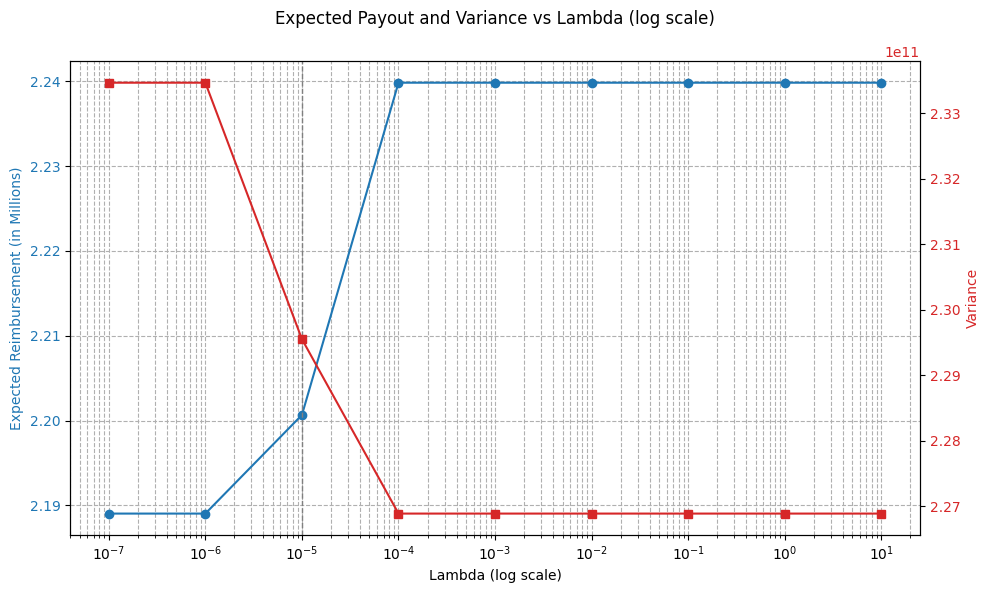

In [1]:
import pickle
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# === Load data ===
with open("optimization_inputs.pkl", "rb") as f:
    optimization_inputs = pickle.load(f)

M = 1e7
n = len(optimization_inputs)

# === Log-spaced lambda values from 10^-7 to 10^1 ===
lambda_values = [10 ** exp for exp in range(-7, 2)]  # -7 to +1
expected_payouts = []
variances = []
lambda_values_used = []

for lambda_penalty in tqdm(lambda_values):
    model = gp.Model("MIQP_Insurance_Limits")
    model.setParam("OutputFlag", 0)

    delta = model.addVars(n, lb=-GRB.INFINITY, name="delta")
    m_vars = {}
    z_vars = {}

    for i, service in enumerate(optimization_inputs):
        m_vars[i] = []
        z_vars[i] = []
        for j in range(len(service["c_ij"])):
            m = model.addVar(lb=0.0, name=f"m_{i}_{j}")
            z = model.addVar(vtype=GRB.BINARY, name=f"z_{i}_{j}")
            m_vars[i].append(m)
            z_vars[i].append(z)

    model.update()

    # Budget neutrality
    model.addConstr(gp.quicksum(delta[i] for i in range(n)) == 0, name="budget_neutral")

    for i, service in enumerate(optimization_inputs):
        limit_i = service["limit"]
        c_ij = service["c_ij"]
        T_i = limit_i + delta[i]

        model.addConstr(delta[i] <= 0.05 * limit_i)
        model.addConstr(delta[i] >= -0.05 * limit_i)

        for j, c in enumerate(c_ij):
            m = m_vars[i][j]
            z = z_vars[i][j]

            model.addConstr(m <= T_i)
            model.addConstr(m <= c)
            model.addConstr(m >= T_i - M * (1 - z))
            model.addConstr(m >= c - M * z)

    # Objective
    quad_obj = gp.QuadExpr()

    for i, service in enumerate(optimization_inputs):
        p_ij = service["p_ij"]
        m_i = m_vars[i]

        expected_i = gp.LinExpr()
        for j in range(len(p_ij)):
            expected_i += p_ij[j] * m_i[j]

        expected_sq = gp.QuadExpr()
        for j in range(len(p_ij)):
            expected_sq += p_ij[j] * m_i[j] * m_i[j]

        squared_expected = gp.QuadExpr()
        for j in range(len(p_ij)):
            for k in range(len(p_ij)):
                squared_expected += p_ij[j] * p_ij[k] * m_i[j] * m_i[k]

        variance_i = expected_sq - squared_expected
        quad_obj += expected_i + lambda_penalty * variance_i

    model.setObjective(quad_obj, GRB.MINIMIZE)
    model.setParam('Presolve', 0)
    model.setParam('Heuristics', 0)
    model.setParam('Cuts', 0)
    model.setParam('MIPFocus', 1)

    model.optimize()

    if model.status == GRB.OPTIMAL:
        expected_val = 0
        variance_val = 0

        for i, service in enumerate(optimization_inputs):
            new_limit = service["limit"] + delta[i].X
            c_ij = service["c_ij"]
            p_ij = service["p_ij"]

            expected_i = 0
            expected_sq_i = 0
            for j in range(len(p_ij)):
                reimbursed = min(new_limit, c_ij[j])
                expected_i += p_ij[j] * reimbursed
                expected_sq_i += p_ij[j] * (reimbursed ** 2)

            variance_i = expected_sq_i - (expected_i ** 2)
            expected_val += expected_i
            variance_val += variance_i

        expected_payouts.append(expected_val)
        variances.append(variance_val)
        lambda_values_used.append(lambda_penalty)
    else:
        print(f"❌ Lambda {lambda_penalty:.1e} → No optimal solution (Status: {model.status})")

# === Plot: Expected payout and variance ===
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-axis: Expected payout
ax1.set_xlabel("Lambda (log scale)")
ax1.set_ylabel("Expected Reimbursement (in Millions)", color='tab:blue')
ax1.semilogx(lambda_values_used, [val / 1e6 for val in expected_payouts],
             color='tab:blue', marker='o', label="Expected Payout")
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, which='both', linestyle='--')
ax1.axvline(x=1e-5, color='gray', linestyle='--', linewidth=1)  # Sensitivity threshold marker

# Right Y-axis: Variance
ax2 = ax1.twinx()
ax2.set_ylabel("Variance", color='tab:red')
ax2.semilogx(lambda_values_used, variances, color='tab:red', marker='s', label="Variance")
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.suptitle("Expected Payout and Variance vs Lambda (log scale)")
fig.tight_layout()
plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 56.20it/s]


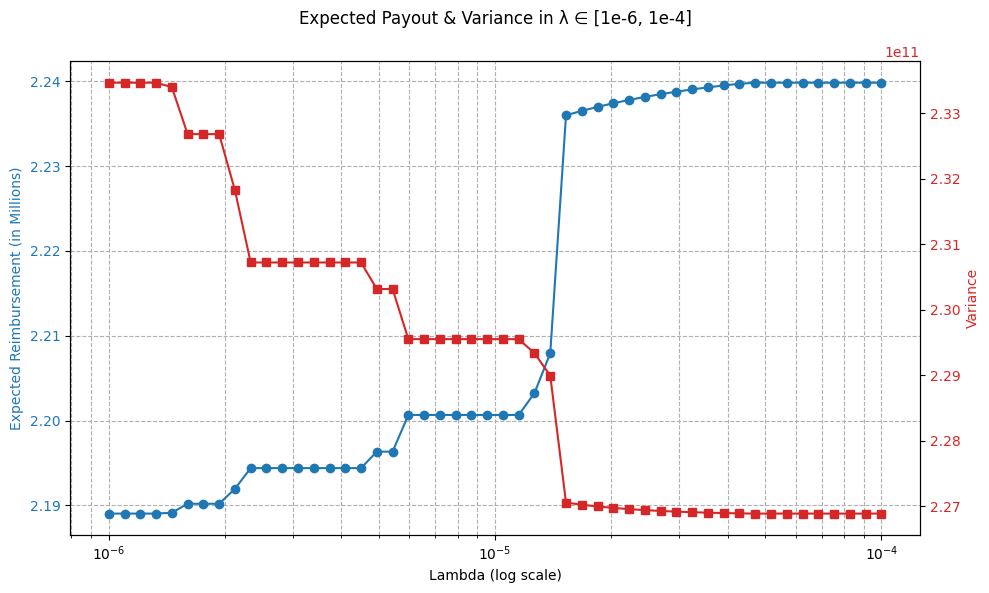

In [2]:
# Fine-grained lambda analysis between 1e-6 and 1e-4
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

lambda_values_zoom = np.logspace(-6, -4, num=50)  # 50 λ values from 1e-6 to 1e-4
expected_zoom = []
variance_zoom = []
limits_zoom = []

for lambda_penalty in tqdm(lambda_values_zoom):
    model = gp.Model("MIQP_Insurance_Limits")
    model.setParam("OutputFlag", 0)

    delta = model.addVars(n, lb=-GRB.INFINITY, name="delta")
    m_vars = {}
    z_vars = {}

    for i, service in enumerate(optimization_inputs):
        m_vars[i] = []
        z_vars[i] = []
        for j in range(len(service["c_ij"])):
            m = model.addVar(lb=0.0, name=f"m_{i}_{j}")
            z = model.addVar(vtype=GRB.BINARY, name=f"z_{i}_{j}")
            m_vars[i].append(m)
            z_vars[i].append(z)

    model.update()
    model.addConstr(gp.quicksum(delta[i] for i in range(n)) == 0)

    for i, service in enumerate(optimization_inputs):
        limit_i = service["limit"]
        c_ij = service["c_ij"]
        T_i = limit_i + delta[i]
        model.addConstr(delta[i] <= 0.05 * limit_i)
        model.addConstr(delta[i] >= -0.05 * limit_i)

        for j, c in enumerate(c_ij):
            m = m_vars[i][j]
            z = z_vars[i][j]
            model.addConstr(m <= T_i)
            model.addConstr(m <= c)
            model.addConstr(m >= T_i - M * (1 - z))
            model.addConstr(m >= c - M * z)

    quad_obj = gp.QuadExpr()
    for i, service in enumerate(optimization_inputs):
        p_ij = service["p_ij"]
        m_i = m_vars[i]
        expected_i = gp.LinExpr()
        for j in range(len(p_ij)):
            expected_i += p_ij[j] * m_i[j]
        expected_sq = gp.QuadExpr()
        for j in range(len(p_ij)):
            expected_sq += p_ij[j] * m_i[j] * m_i[j]
        squared_expected = gp.QuadExpr()
        for j in range(len(p_ij)):
            for k in range(len(p_ij)):
                squared_expected += p_ij[j] * p_ij[k] * m_i[j] * m_i[k]
        variance_i = expected_sq - squared_expected
        quad_obj += expected_i + lambda_penalty * variance_i

    model.setObjective(quad_obj, GRB.MINIMIZE)
    model.setParam('Presolve', 0)
    model.setParam('Heuristics', 0)
    model.setParam('Cuts', 0)
    model.setParam('MIPFocus', 1)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        expected_val = 0
        variance_val = 0
        for i, service in enumerate(optimization_inputs):
            new_limit = service["limit"] + delta[i].X
            c_ij = service["c_ij"]
            p_ij = service["p_ij"]
            expected_i = 0
            expected_sq_i = 0
            for j in range(len(p_ij)):
                reimbursed = min(new_limit, c_ij[j])
                expected_i += p_ij[j] * reimbursed
                expected_sq_i += p_ij[j] * (reimbursed ** 2)
            variance_i = expected_sq_i - expected_i ** 2
            expected_val += expected_i
            variance_val += variance_i

        expected_zoom.append(expected_val)
        variance_zoom.append(variance_val)
    else:
        print(f"λ = {lambda_penalty:.1e} failed.")

# === Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel("Lambda (log scale)")
ax1.set_ylabel("Expected Reimbursement (in Millions)", color='tab:blue')
ax1.semilogx(lambda_values_zoom, [v / 1e6 for v in expected_zoom],
             color='tab:blue', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, which='both', linestyle='--')

ax2 = ax1.twinx()
ax2.set_ylabel("Variance", color='tab:red')
ax2.semilogx(lambda_values_zoom, variance_zoom, color='tab:red', marker='s')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.suptitle("Expected Payout & Variance in λ ∈ [1e-6, 1e-4]")
fig.tight_layout()
plt.show()
